# 13 — EDA fase 4: estructura espacial

**Pregunta guía:** ¿el dengue en Piura es un fenómeno regional homogéneo o local? ¿Hay señales de propagación entre distritos?

Dataset: `data/silver/integrado/meteo_socio_epi_piura_2017_2025.csv` (solo lectura). Distancias, pesos espaciales, correlaciones y estados de vecinos se calculan **en memoria** con numpy; nada se guarda en `data/` ni es una feature.

**Limitaciones de partida:**
- El dataset trae solo **centroides** (lat/lon), sin polígonos ni altitud. Por eso no hay mapas coropléticos, la vecindad se define por distancia entre centroides y "costa/sierra" se aproxima por provincia (Ayabaca y Huancabamba = sierra).

**Supuestos de trabajo** (los de las fases anteriores):
- 2025 va incluido pero marcado aparte.
- Se usa la población del dataset.
- Se usa la marca ilustrativa D1 (tasa ≥ 10 por 100 000 hab.).
- Las temporadas van de la semana 35 a la 34 (fase 3).

Etiquetas: **Observación** · **Hipótesis** · **Implicación**.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import linkage, leaves_list, fcluster
from scipy.spatial.distance import squareform

from src.eda.carga import cargar_integrado, OBJETIVO
from src.eda.objetivo import tasa_100k, brote_umbral_tasa, marcar_arranque, sin_marca_previa
from src.eda.temporal import asignar_temporada
from src.eda.espacial import (distancias_km, pesos_knn, pesos_inverso_distancia, moran_i, estado_vecinos_rezagado,
                              rr_mantel_haenszel, mantel)
from src.eda.estilo import aplicar_estilo, guardar_figura, guardar_metricas, COLORES

aplicar_estilo()
FASE = "fase4_espacial"
H, K, SEMANA_CORTE = 4, 5, 35
SIERRA = ["Ayabaca", "Huancabamba"]
M = {"horizonte_semanas": H, "k_vecinos": K, "semana_corte_temporada": SEMANA_CORTE}

df = cargar_integrado()
df["temporada"] = asignar_temporada(df["anio"], df["semana"], SEMANA_CORTE)   # en memoria
df["b"] = brote_umbral_tasa(df, 10).astype(float)                           # D1 ilustrativa, en memoria
geo = df.drop_duplicates("ubigeo").set_index("ubigeo")[["provincia", "distrito", "lat", "lon"]]
geo["distrito"] = geo["distrito"].str.replace(r"_s$", "", regex=True)
geo.loc[geo["distrito"].duplicated(keep=False), "distrito"] += " (" + geo["provincia"] + ")"
U = list(geo.index)
D = distancias_km(geo["lat"], geo["lon"])
tot = df.groupby("ubigeo").agg(casos=(OBJETIVO, "sum"), pob=("poblacion", "mean")).loc[U]
tot["incidencia"] = tasa_100k(tot["casos"], tot["pob"])
tot = tot.join(geo)

vecino_mas_cercano = np.sort(np.where(D > 0, D, np.inf), axis=1)[:, 0]
M["distancia_vecino_mas_cercano_km_mediana_min_max"] = [round(float(np.median(vecino_mas_cercano)), 1),
                                                       round(float(vecino_mas_cercano.min()), 1), round(float(vecino_mas_cercano.max()), 1)]
M["distancia_k_vecinos_km_mediana"] = round(float(np.median(np.sort(np.where(D > 0, D, np.inf), axis=1)[:, :K])), 1)
print(f"Distancia al vecino más cercano (km): mediana, mín, máx = {M['distancia_vecino_mas_cercano_km_mediana_min_max']}; "
      f"mediana de la distancia a los {K} vecinos más cercanos: {M['distancia_k_vecinos_km_mediana']} km.")

Distancia al vecino más cercano (km): mediana, mín, máx = [12.3, 4.9, 43.1]; mediana de la distancia a los 5 vecinos más cercanos: 19.7 km.


## 1. ¿Dónde está el dengue? Heterogeneidad entre distritos y provincias

**Qué quiero saber:** cómo se reparte la incidencia acumulada 2017-2025 en el espacio y cuánto difieren las provincias entre sí y por dentro.

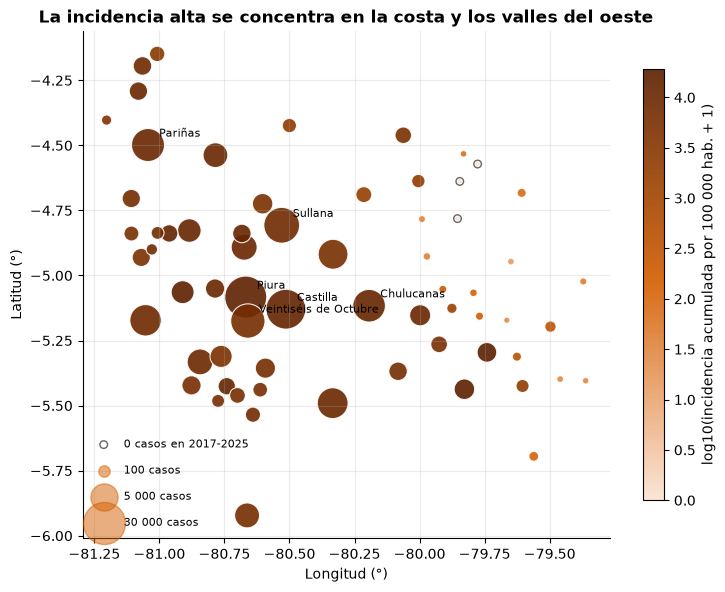

In [2]:
fig, ax = plt.subplots(figsize=(8.5, 8))
cmap = LinearSegmentedColormap.from_list("inc", ["#fbe3d2", COLORES["casos"], "#5a1f00"])
orden = tot.sort_values("casos", ascending=False)
tam = 15 + 900 * np.sqrt(orden["casos"] / orden["casos"].max())
sc = ax.scatter(orden["lon"], orden["lat"], s=tam, c=np.log10(orden["incidencia"] + 1), cmap=cmap,
                edgecolor="white", linewidth=0.8, alpha=0.9)
cero = orden[orden["casos"] == 0]
ax.scatter(cero["lon"], cero["lat"], s=30, facecolor="none", edgecolor=COLORES["referencia"], label="0 casos en 2017-2025")
for u in orden.head(6).index:
    ax.annotate(orden.loc[u, "distrito"], (orden.loc[u, "lon"], orden.loc[u, "lat"]), xytext=(8, 6), textcoords="offset points", fontsize=8)
cb = fig.colorbar(sc, ax=ax, shrink=0.7)
cb.set_label("log10(incidencia acumulada por 100 000 hab. + 1)")
for n in [100, 5000, 30000]:
    ax.scatter([], [], s=15 + 900 * np.sqrt(n / orden["casos"].max()), color=COLORES["casos"], alpha=0.5, label=f"{n:,} casos".replace(",", " "))
ax.set(xlabel="Longitud (°)", ylabel="Latitud (°)", title="La incidencia alta se concentra en la costa y los valles del oeste")
ax.set_aspect("equal")
ax.legend(loc="lower left", fontsize=8, labelspacing=1.3)
guardar_figura(fig, FASE, "01_mapa_incidencia_acumulada")
plt.show()

Incidencia acumulada por provincia (por 100 000 hab.): {'Piura': 9919.0, 'Morropón': 9721.0, 'Talara': 9305.0, 'Paita': 9091.0, 'Sullana': 8610.0, 'Sechura': 6908.0, 'Ayabaca': 694.0, 'Huancabamba': 330.0}
Mediana distrital sierra vs resto: [41.0, 7365.0]. La provincia explica el 67.1 % de la varianza de log1p(incidencia) entre distritos; solo entre distritos de costa, el 17.7 %.


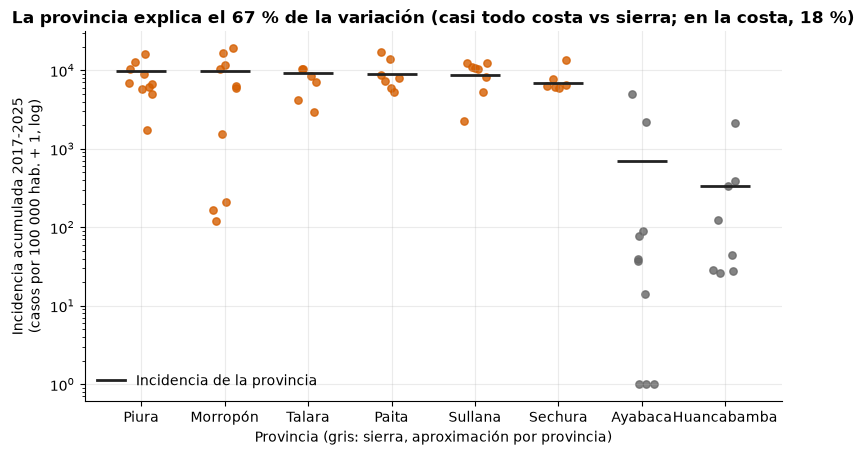

In [3]:
por_prov = tot.groupby("provincia").agg(distritos=("casos", "size"), casos=("casos", "sum"), pob=("pob", "sum"),
                                        inc_mediana=("incidencia", "median"), inc_min=("incidencia", "min"), inc_max=("incidencia", "max"))
por_prov["incidencia_provincial"] = tasa_100k(por_prov["casos"], por_prov["pob"])
por_prov = por_prov.sort_values("incidencia_provincial", ascending=False)
M["incidencia_acumulada_por_provincia"] = {p: round(float(v), 0) for p, v in por_prov["incidencia_provincial"].items()}
M["incidencia_acumulada_rango_dentro_de_provincia"] = {p: [round(float(f.inc_min), 0), round(float(f.inc_max), 0)] for p, f in por_prov.iterrows()}
es_sierra = tot["provincia"].isin(SIERRA)
M["incidencia_acumulada_mediana_sierra_vs_resto"] = [round(float(tot.loc[es_sierra, "incidencia"].median()), 0),
                                                    round(float(tot.loc[~es_sierra, "incidencia"].median()), 0)]
# Proporción de la varianza de log(incidencia) entre provincias (R² de un ANOVA de un factor)
li = np.log1p(tot["incidencia"])
def r2_factor(y, g):
    return 1 - y.groupby(g).transform(lambda s: s - s.mean()).pow(2).sum() / (y - y.mean()).pow(2).sum()
M["r2_provincia_log_incidencia"] = round(float(r2_factor(li, tot["provincia"])), 3)
M["r2_provincia_log_incidencia_solo_costa"] = round(float(r2_factor(li[~es_sierra], tot.loc[~es_sierra, "provincia"])), 3)
print("Incidencia acumulada por provincia (por 100 000 hab.):", M["incidencia_acumulada_por_provincia"])
print(f"Mediana distrital sierra vs resto: {M['incidencia_acumulada_mediana_sierra_vs_resto']}. "
      f"La provincia explica el {M['r2_provincia_log_incidencia'] * 100:.1f} % de la varianza de log1p(incidencia) entre distritos; "
      f"solo entre distritos de costa, el {M['r2_provincia_log_incidencia_solo_costa'] * 100:.1f} %.")

fig, ax = plt.subplots(figsize=(9, 4.8))
provs = list(por_prov.index)
for i, p in enumerate(provs):
    g = tot[tot["provincia"] == p]
    jitter = np.random.default_rng(i).uniform(-0.15, 0.15, len(g))
    ax.scatter(np.full(len(g), i) + jitter, g["incidencia"] + 1, s=28, color=COLORES["referencia"] if p in SIERRA else COLORES["casos"], alpha=0.8)
    ax.hlines(por_prov.loc[p, "incidencia_provincial"] + 1, i - 0.3, i + 0.3, color="#222222", lw=2)
ax.set_yscale("log")
ax.set_xticks(range(len(provs)), provs)
ax.set(ylabel="Incidencia acumulada 2017-2025\n(casos por 100 000 hab. + 1, log)", xlabel="Provincia (gris: sierra, aproximación por provincia)",
       title=f"La provincia explica el {M['r2_provincia_log_incidencia'] * 100:.0f} % de la variación (casi todo costa vs sierra; en la costa, {M['r2_provincia_log_incidencia_solo_costa'] * 100:.0f} %)")
ax.plot([], [], color="#222222", lw=2, label="Incidencia de la provincia")
ax.legend(loc="lower left")
guardar_figura(fig, FASE, "02_incidencia_por_provincia")
plt.show()

**Observación.** La incidencia acumulada se concentra en la costa y los valles del oeste. Ayabaca y Huancabamba (sierra, aproximada por provincia) tienen incidencias mucho menores. La provincia explica una parte grande de la variación entre distritos, pero casi todo es la separación costa/sierra: entre los distritos de costa, la provincia explica poco (cifras arriba), y dentro de cada provincia hay distritos con incidencias muy distintas.
**Implicación.**
- Un modelo global necesita alguna forma de capturar el nivel propio de cada distrito, ya sea con efectos o indicadores por distrito o provincia, o con historia propia. Si no la tiene, promediará distritos muy distintos.
- Como la provincia no basta, conviene capturar el nivel a nivel distrital.

## 2. Autocorrelación espacial (I de Moran)

**Qué quiero saber:** si los distritos cercanos tienen incidencias parecidas más de lo esperado al azar. Se mide sobre `log1p(incidencia acumulada)`, (a) en todos los distritos y (b) solo en la costa, para ver si el agrupamiento es algo más que la división costa/sierra. También se calcula por temporada.
Pesos: k = 5 vecinos más cercanos (y sensibilidad con k = 3, k = 8 e inverso de la distancia). Prueba por permutación (999, semilla 42).

In [4]:
x = np.log1p(tot["incidencia"]).to_numpy()
costa = np.array([p not in SIERRA for p in tot["provincia"]])
filas = {}
for nombre_w, w in [("knn3", pesos_knn(D, 3)), ("knn5", pesos_knn(D, K)), ("knn8", pesos_knn(D, 8)), ("inverso_distancia", pesos_inverso_distancia(D))]:
    filas[f"todos_{nombre_w}"] = moran_i(x, w)
filas["costa_knn5"] = moran_i(x[costa], pesos_knn(D[np.ix_(costa, costa)], K))
for t in [2017, 2022, 2023, 2024, 2025]:
    g = df[df["temporada"] == t].groupby("ubigeo").agg(c=(OBJETIVO, "sum"), p=("poblacion", "mean")).loc[U]
    filas[f"temporada_{t}_knn5"] = moran_i(np.log1p(tasa_100k(g["c"], g["p"])).to_numpy(), pesos_knn(D, K))
moran = pd.DataFrame(filas).T[["I", "esperado", "p_valor"]].round(3)
# Con 999 permutaciones el p mínimo posible es 0.001: se lee como "p ≤ 0.001". La temporada 2017 es parcial (semanas 1-34 de 2017).
M["moran"] = {k: {kk: float(vv) for kk, vv in f.items()} for k, f in moran.iterrows()}
moran

,I,esperado,p_valor
todos_knn3,0.756,-0.016,0.001
todos_knn5,0.693,-0.016,0.001
todos_knn8,0.608,-0.016,0.001
todos_inverso_distancia,0.272,-0.016,0.001
costa_knn5,0.333,-0.022,0.002
temporada_2017_knn5,0.390,-0.016,0.001
temporada_2022_knn5,0.515,-0.016,0.001
temporada_2023_knn5,0.658,-0.016,0.001
temporada_2024_knn5,0.644,-0.016,0.001
temporada_2025_knn5,0.589,-0.016,0.001


**Observación.** El I de Moran es positivo y significativo con todas las definiciones de vecindad, y también **solo dentro de la costa**, aunque ahí es menor. El agrupamiento no se explica solo por la división costa/sierra. En cada temporada de brote se repite el patrón (tabla; p = 0.001 es el mínimo posible con 999 permutaciones, es decir, p ≤ 0.001). La temporada 2017 es parcial (semanas 1-34), así que su valor no es directamente comparable con las demás.
**Hipótesis.** Condiciones compartidas por distritos cercanos (clima, conectividad, sistema de salud) o transmisión entre ellos; el I de Moran no distingue entre las dos.
**Implicación.** La información de los vecinos es un candidato razonable, y la sección 5 lo mira desde el punto de vista temporal. Como la autocorrelación espacial es positiva, una validación que ponga distritos vecinos en entrenamiento y prueba en la **misma** semana sería optimista. Eso refuerza partir por tiempo, no por distrito.

## 3. Sincronía entre distritos: ¿una señal regional común o dinámicas locales?

**Qué quiero saber:** cuánto se parecen las series semanales `log1p(casos)` de los 31 distritos activos (≥ 20 % de semanas con casos). Se miran (a) en bruto y (b) después de quitar la señal regional común (restando a cada semana la media de los distritos activos), y se pregunta si la similitud decae con la distancia. También si un agrupamiento jerárquico de las series residuales produce grupos geográficos.

In [5]:
ancho = np.log1p(df.pivot(index="semana_inicio", columns="ubigeo", values=OBJETIVO))
activos = [u for u in U if (ancho[u] > 0).mean() >= 0.2]
residual = ancho[activos].sub(ancho[activos].mean(axis=1), axis=0)
c_bruta = ancho[activos].corr(method="spearman")
c_resid = residual.corr(method="spearman")
iu = np.triu_indices(len(activos), 1)
pares = pd.DataFrame({"bruta": c_bruta.to_numpy()[iu], "residual": c_resid.to_numpy()[iu],
                      "km": pd.DataFrame(D, index=U, columns=U).loc[activos, activos].to_numpy()[iu]})
M["n_distritos_activos"] = len(activos)
M["spearman_pares_bruta_p25_mediana_p75"] = [round(float(pares["bruta"].quantile(q)), 2) for q in (0.25, 0.5, 0.75)]
M["spearman_pares_residual_p25_mediana_p75"] = [round(float(pares["residual"].quantile(q)), 2) for q in (0.25, 0.5, 0.75)]
M["rho_similitud_vs_distancia_bruta"] = round(float(spearmanr(pares["bruta"], pares["km"]).statistic), 3)
M["rho_similitud_vs_distancia_residual"] = round(float(spearmanr(pares["residual"], pares["km"]).statistic), 3)
cerca = pares["km"] <= 30
M["residual_mediana_pares_hasta_30km_vs_mas_de_30km"] = [round(float(pares.loc[cerca, "residual"].median()), 2), round(float(pares.loc[~cerca, "residual"].median()), 2)]
M["n_pares_hasta_30km"] = int(cerca.sum())

# Los pares no son independientes: prueba de Mantel (permutación de distritos) para la relación similitud residual-distancia
Dact = pd.DataFrame(D, index=U, columns=U).loc[activos, activos].to_numpy()
M["mantel_residual_vs_distancia"] = mantel(c_resid.to_numpy(), Dact, permutaciones=999)
M["mantel_bruta_vs_distancia"] = mantel(c_bruta.to_numpy(), Dact, permutaciones=999)
# Sensibilidad: sin los distritos de actividad casi continua (casos en > 50 % de sus semanas)
continuos = [u for u in activos if (ancho[u] > 0).mean() > 0.5]
resto = [u for u in activos if u not in continuos]
res2 = ancho[resto].sub(ancho[resto].mean(axis=1), axis=0).corr(method="spearman")
D2 = pd.DataFrame(D, index=U, columns=U).loc[resto, resto].to_numpy()
iu2 = np.triu_indices(len(resto), 1)
M["distritos_actividad_continua_excluidos"] = [geo.loc[u, "distrito"] for u in continuos]
M["mantel_residual_vs_distancia_sin_continuos"] = mantel(res2.to_numpy(), D2, permutaciones=999)
cerca2 = D2[iu2] <= 30
M["residual_mediana_hasta_30km_vs_mas_sin_continuos"] = [round(float(np.median(res2.to_numpy()[iu2][cerca2])), 2),
                                                        round(float(np.median(res2.to_numpy()[iu2][~cerca2])), 2)]
print("Mantel (Spearman, 999 permutaciones de distritos):", {k: M[k] for k in ["mantel_bruta_vs_distancia", "mantel_residual_vs_distancia",
      "mantel_residual_vs_distancia_sin_continuos"]})
print("Sin distritos continuos:", M["distritos_actividad_continua_excluidos"], "| mediana residual ≤ 30 km vs > 30 km:",
      M["residual_mediana_hasta_30km_vs_mas_sin_continuos"])

Z = linkage(squareform(1 - c_resid.to_numpy(), checks=False), method="average")
grupos = pd.Series(fcluster(Z, t=4, criterion="maxclust"), index=activos, name="grupo")
tabla_grupos = pd.crosstab(grupos, geo.loc[activos, "provincia"])
M["grupos_residuales_por_provincia"] = {int(g): {p: int(n) for p, n in fila.items() if n} for g, fila in tabla_grupos.iterrows()}
print(f"Pares de distritos activos (n = {len(pares)}): Spearman bruta p25/mediana/p75 = {M['spearman_pares_bruta_p25_mediana_p75']}; "
      f"residual = {M['spearman_pares_residual_p25_mediana_p75']}.")
print(f"Similitud vs distancia (Spearman): bruta {M['rho_similitud_vs_distancia_bruta']}, residual {M['rho_similitud_vs_distancia_residual']}. "
      f"Mediana residual en pares a ≤ 30 km vs > 30 km: {M['residual_mediana_pares_hasta_30km_vs_mas_de_30km']} (n ≤ 30 km = {M['n_pares_hasta_30km']}).")
tabla_grupos

Mantel (Spearman, 999 permutaciones de distritos): {'mantel_bruta_vs_distancia': {'rho': -0.4656104541526829, 'p_valor': 0.001}, 'mantel_residual_vs_distancia': {'rho': -0.10149033021907987, 'p_valor': 0.072}, 'mantel_residual_vs_distancia_sin_continuos': {'rho': -0.39545611506685124, 'p_valor': 0.001}}
Sin distritos continuos: ['Piura', 'Castilla', 'Catacaos', 'Tambo Grande', 'Veintiséis de Octubre', 'Chulucanas', 'Sullana'] | mediana residual ≤ 30 km vs > 30 km: [0.21, 0.07]
Pares de distritos activos (n = 465): Spearman bruta p25/mediana/p75 = [0.56, 0.62, 0.68]; residual = [-0.18, 0.06, 0.25].
Similitud vs distancia (Spearman): bruta -0.466, residual -0.101. Mediana residual en pares a ≤ 30 km vs > 30 km: [0.22, 0.05] (n ≤ 30 km = 55).


provincia,Morropón,Paita,Piura,Sechura,Sullana,Talara
grupo,,,,,,
1,1,0,5,0,1,0
2,0,1,1,1,1,1
3,0,0,0,0,2,0
4,5,1,3,2,3,3


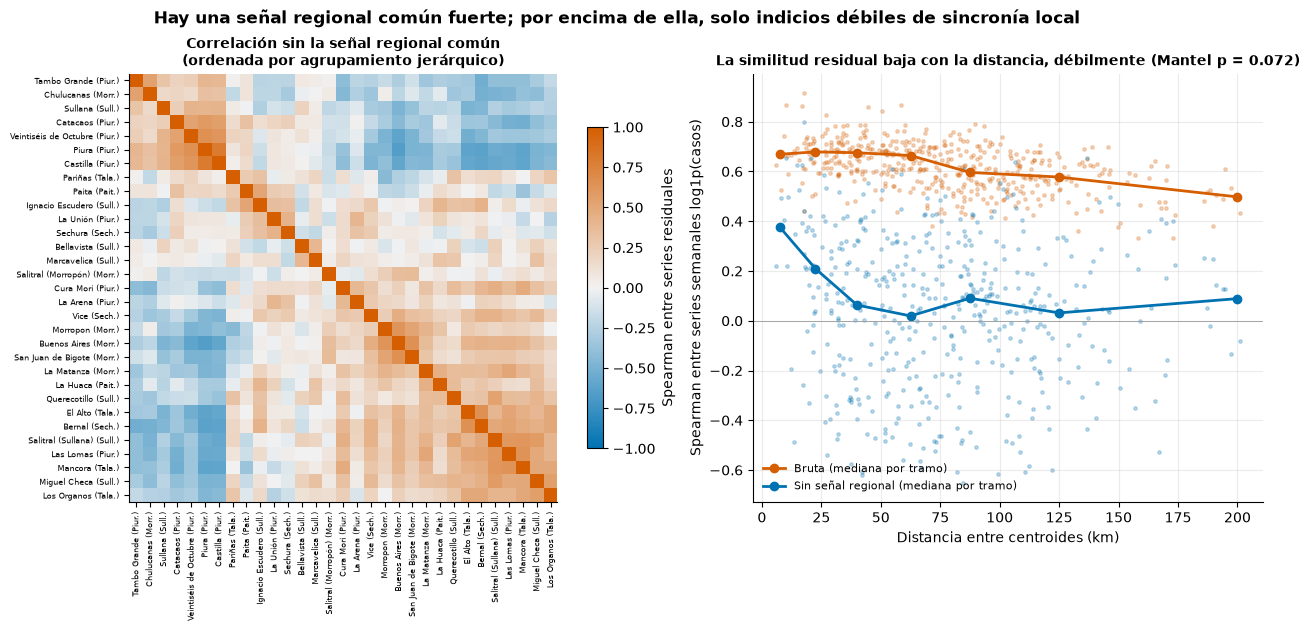

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.2), gridspec_kw={"width_ratios": [1.15, 1]}, layout="constrained")
orden_h = [activos[i] for i in leaves_list(Z)]
cmap_div = LinearSegmentedColormap.from_list("div", [COLORES["clima"], "#f2f2f2", COLORES["casos"]])
im = axes[0].imshow(c_resid.loc[orden_h, orden_h].to_numpy(), cmap=cmap_div, vmin=-1, vmax=1)
etq = [f"{geo.loc[u, 'distrito']} ({geo.loc[u, 'provincia'][:4]}.)" for u in orden_h]
axes[0].set_xticks(range(len(orden_h)), etq, rotation=90, fontsize=6)
axes[0].set_yticks(range(len(orden_h)), etq, fontsize=6)
axes[0].grid(False)
fig.colorbar(im, ax=axes[0], shrink=0.75, label="Spearman entre series residuales")
axes[0].set_title("Correlación sin la señal regional común\n(ordenada por agrupamiento jerárquico)", fontsize=10)

bins = [0, 15, 30, 50, 75, 100, 150, 250]
pares["tramo"] = pd.cut(pares["km"], bins)
med = pares.groupby("tramo", observed=True)[["bruta", "residual"]].median()
centros = [(b.left + b.right) / 2 for b in med.index]
axes[1].scatter(pares["km"], pares["bruta"], s=6, color=COLORES["casos"], alpha=0.25)
axes[1].scatter(pares["km"], pares["residual"], s=6, color=COLORES["clima"], alpha=0.25)
axes[1].plot(centros, med["bruta"], color=COLORES["casos"], lw=2, marker="o", label="Bruta (mediana por tramo)")
axes[1].plot(centros, med["residual"], color=COLORES["clima"], lw=2, marker="o", label="Sin señal regional (mediana por tramo)")
axes[1].axhline(0, color="#999999", lw=0.6)
axes[1].set(xlabel="Distancia entre centroides (km)", ylabel="Spearman entre series semanales log1p(casos)")
axes[1].set_title(f"La similitud residual baja con la distancia, débilmente (Mantel p = {M['mantel_residual_vs_distancia']['p_valor']:.3f})", fontsize=10)
axes[1].legend(loc="lower left", fontsize=8)
fig.suptitle("Hay una señal regional común fuerte; por encima de ella, solo indicios débiles de sincronía local", fontweight="bold")
guardar_figura(fig, FASE, "03_sincronia_distritos")
plt.show()

**Observación.** En bruto, las series de los distritos activos están bastante correlacionadas: todos comparten las temporadas. Al quitar la señal regional común, la correlación típica cae cerca de cero. La que queda es mayor entre distritos cercanos, pero la relación con la distancia es **débil**: la prueba de Mantel (que respeta que los pares no son independientes) no es concluyente con todos los distritos activos, y se refuerza al excluir los distritos de actividad casi continua (cifras arriba). Son indicios de sincronía local, no una conclusión firme. Cautela: al restar la media común, los distritos con actividad casi continua (el bloque de ciudades grandes de Piura, Castilla y Veintiséis de Octubre, más Tambo Grande y Chulucanas) quedan correlacionados negativamente con el resto. Eso es en parte un artefacto de restar la media, no una dinámica opuesta. El agrupamiento jerárquico de las series residuales (4 grupos) **no reproduce las provincias**: solo un grupo está dominado por distritos de la provincia de Piura y el grupo más grande mezcla distritos de las seis provincias de costa (tabla).
**Implicación.**
- Domina un factor **regional** común (que puede venir del clima regional o de la estacionalidad compartida). Hay indicios de una componente **local** compartida con los vecinos, pero es débil y sensible a cómo se quita la señal común.
- Un modelo global con información regional más la información de los vecinos cercanos parece más adecuado que modelos independientes por distrito. Los grupos del agrupamiento no dan una partición geográfica clara, y con 31 distritos activos serían frágiles para modelos por grupo. Recomendación, no decisión.

## 4. Propagación: ¿quién arranca primero en cada temporada grande?

**Qué quiero saber:** en las temporadas 2017, 2023 y 2024, en qué semana de la temporada tuvo cada distrito su **primer arranque** (primera semana D1 sin D1 en las 8 semanas previas, como en la fase 3), cuánto se dispersan esos arranques y si ocurren después en los distritos más alejados de los primeros.
**Censura en 2017:** la temporada 2017 empieza en la primera semana del panel, así que no puede haber arranques antes de la semana 9. Los "primeros" de 2017 son un artefacto de ese borde, y 18 distritos que ya tenían D1 en las semanas 1-8 quedan fuera. Por eso se mide la sensibilidad al punto de referencia: la correlación se recalcula tomando como foco, uno por uno, a cada distrito que arrancó en las 2 primeras semanas con arranques de la temporada, y también con el primer D1 en lugar del primer arranque.
Se usa el arranque y no el primer D1 porque la temporada 2024 empieza (semana 35 de 2023) con el brote de 2023 todavía activo: ahí el primer D1 es una continuación, no un inicio. Los distritos que ya estaban activos al empezar la temporada y no vuelven a arrancar quedan fuera. En 2017 las primeras 8 semanas del panel no tienen historia previa, así que no pueden contener arranques.
Distancia de referencia: al centroide de los distritos que arrancaron en la primera semana con algún arranque en esa temporada.

In [7]:
inicio_temp = df.groupby("temporada")["semana_inicio"].transform("min")
df["semana_de_temporada"] = ((df["semana_inicio"] - inicio_temp).dt.days // 7) + 1
res_prop, inicios = {}, {}
prev8_ini = df.groupby("ubigeo")["b"].transform(lambda s: s.shift(1).rolling(8, min_periods=8).max())
df_arr = (df["b"] == 1) & (prev8_ini == 0)
for t in [2017, 2023, 2024]:
    g = df[(df["temporada"] == t) & df_arr]
    ini = g.groupby("ubigeo")["semana_de_temporada"].min()
    activos_al_inicio = df[(df["temporada"] == t) & (df["semana_de_temporada"] <= 8) & (df["b"] == 1)]["ubigeo"].nunique()
    primeros = ini[ini == ini.min()].index
    lat0, lon0 = geo.loc[primeros, "lat"].mean(), geo.loc[primeros, "lon"].mean()
    d0 = distancias_km(np.r_[lat0, geo.loc[ini.index, "lat"]], np.r_[lon0, geo.loc[ini.index, "lon"]])[0, 1:]
    rho = spearmanr(ini.to_numpy(), d0)
    inicios[t] = ini
    # Sensibilidad 1: foco = cada distrito que arrancó en las 2 primeras semanas con arranques
    focos = ini[ini.isin(sorted(ini.unique())[:2])].index   # las 2 primeras semanas (distintas) con arranques
    rhos_foco = []
    for f in focos:
        dist_f = distancias_km(np.r_[geo.loc[f, "lat"], geo.loc[ini.index, "lat"]], np.r_[geo.loc[f, "lon"], geo.loc[ini.index, "lon"]])[0, 1:]
        otros = ini.index != f
        rhos_foco.append(spearmanr(ini.to_numpy()[otros], dist_f[otros]).statistic)
    # Sensibilidad 2: primer D1 de la temporada en lugar del primer arranque
    ini_d1 = df[(df["temporada"] == t) & (df["b"] == 1)].groupby("ubigeo")["semana_de_temporada"].min()
    prim_d1 = ini_d1[ini_d1 == ini_d1.min()].index
    d1_ref = distancias_km(np.r_[geo.loc[prim_d1, "lat"].mean(), geo.loc[ini_d1.index, "lat"]],
                           np.r_[geo.loc[prim_d1, "lon"].mean(), geo.loc[ini_d1.index, "lon"]])[0, 1:]
    rho_d1 = spearmanr(ini_d1.to_numpy(), d1_ref)
    res_prop[t] = {
        "distritos_con_arranque": int(len(ini)),
        "distritos_con_D1_en_las_primeras_8_semanas": int(activos_al_inicio),
        "primeros": [geo.loc[u, "distrito"] for u in primeros],
        "semana_inicio_min_mediana_max": [int(ini.min()), float(ini.median()), int(ini.max())],
        "semana_inicio_p25_p75": [float(ini.quantile(0.25)), float(ini.quantile(0.75))],
        "rho_inicio_vs_distancia_a_primeros": round(float(rho.statistic), 3),
        "p_valor": round(float(rho.pvalue), 4),
        "focos_alternativos_n": int(len(focos)),
        "rho_con_focos_alternativos_min_max": [round(float(np.nanmin(rhos_foco)), 3), round(float(np.nanmax(rhos_foco)), 3)],
        "rho_con_primer_D1": round(float(rho_d1.statistic), 3),
        "p_valor_con_primer_D1": round(float(rho_d1.pvalue), 4),
    }
M["propagacion"] = {int(t): v for t, v in res_prop.items()}
for t, v in res_prop.items():
    print(t, v)

2017 {'distritos_con_arranque': 38, 'distritos_con_D1_en_las_primeras_8_semanas': 18, 'primeros': ['Colan', 'Querecotillo'], 'semana_inicio_min_mediana_max': [9, 14.0, 21], 'semana_inicio_p25_p75': [12.0, 16.0], 'rho_inicio_vs_distancia_a_primeros': 0.459, 'p_valor': 0.0037, 'focos_alternativos_n': 6, 'rho_con_focos_alternativos_min_max': [-0.036, 0.442], 'rho_con_primer_D1': 0.272, 'p_valor_con_primer_D1': 0.0463}
2023 {'distritos_con_arranque': 51, 'distritos_con_D1_en_las_primeras_8_semanas': 8, 'primeros': ['La Matanza'], 'semana_inicio_min_mediana_max': [3, 27.0, 45], 'semana_inicio_p25_p75': [22.0, 31.5], 'rho_inicio_vs_distancia_a_primeros': 0.133, 'p_valor': 0.3523, 'focos_alternativos_n': 3, 'rho_con_focos_alternativos_min_max': [-0.144, 0.126], 'rho_con_primer_D1': 0.388, 'p_valor_con_primer_D1': 0.0037}
2024 {'distritos_con_arranque': 26, 'distritos_con_D1_en_las_primeras_8_semanas': 43, 'primeros': ['Las Lomas'], 'semana_inicio_min_mediana_max': [6, 23.0, 38], 'semana_inici

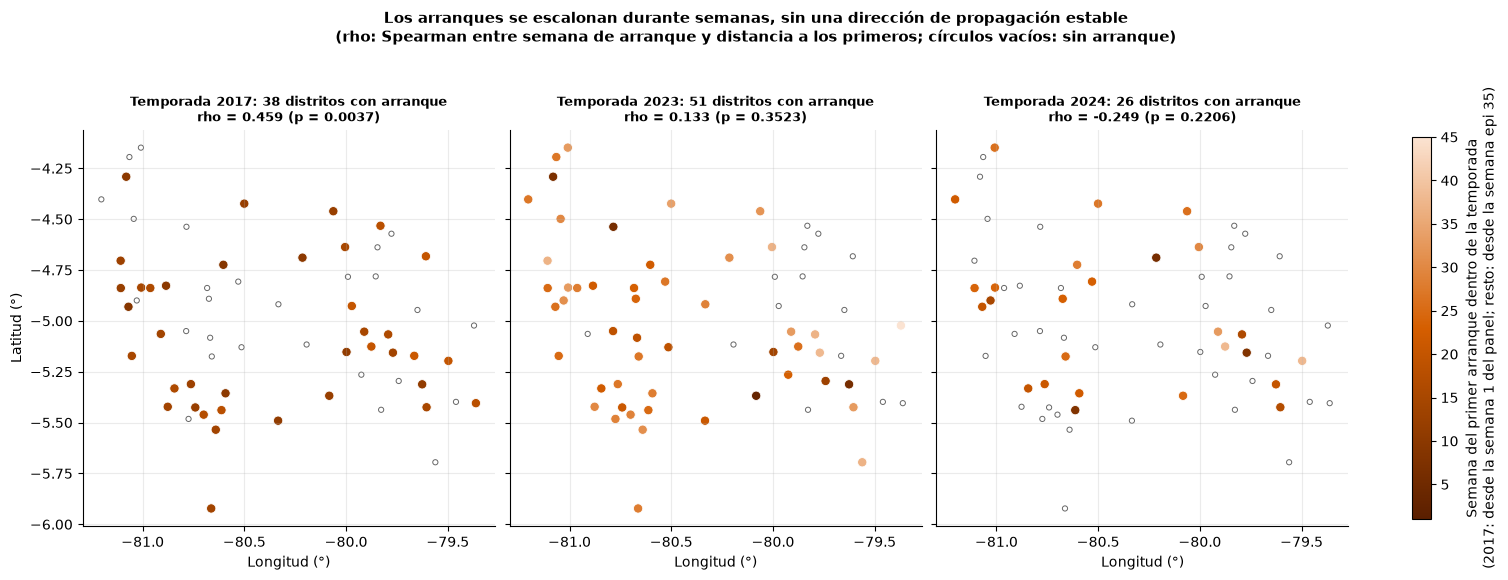

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharex=True, sharey=True, layout="constrained")
cmap_ini = LinearSegmentedColormap.from_list("ini", ["#5a1f00", COLORES["casos"], "#fbe3d2"])
vmax = max(int(v.max()) for v in inicios.values())
for ax, t in zip(axes, [2017, 2023, 2024]):
    ini = inicios[t]
    sin = [u for u in U if u not in ini.index]
    ax.scatter(geo.loc[sin, "lon"], geo.loc[sin, "lat"], s=14, facecolor="none", edgecolor=COLORES["referencia"], lw=0.7)
    sc = ax.scatter(geo.loc[ini.index, "lon"], geo.loc[ini.index, "lat"], c=ini.to_numpy(), cmap=cmap_ini, vmin=1, vmax=vmax,
                    s=45, edgecolor="white", linewidth=0.6)
    v = res_prop[t]
    ax.set_title(f"Temporada {t}: {v['distritos_con_arranque']} distritos con arranque\nrho = {v['rho_inicio_vs_distancia_a_primeros']} (p = {v['p_valor']})", fontsize=9)
    ax.set_aspect("equal")
    ax.set_xlabel("Longitud (°)")
    ax.set_xticks([-81.0, -80.5, -80.0, -79.5])
axes[0].set_ylabel("Latitud (°)")
cb = fig.colorbar(sc, ax=axes, shrink=0.7)
cb.set_label(f"Semana del primer arranque dentro de la temporada\n(2017: desde la semana 1 del panel; resto: desde la semana epi {SEMANA_CORTE})")
fig.suptitle("Los arranques se escalonan durante semanas, sin una dirección de propagación estable\n(rho: Spearman entre semana de arranque y distancia a los primeros; círculos vacíos: sin arranque)",
             fontweight="bold", fontsize=11)
guardar_figura(fig, FASE, "04_inicio_por_temporada")
plt.show()

**Observación.** Los arranques no ocurren todos a la vez: entre el primero y el último pasan muchas semanas (cifras arriba). La correlación entre la semana de arranque y la distancia a los primeros es positiva en 2017, débil en 2023 y negativa en 2024. Además, **cambia mucho según qué distrito se tome como foco** (rango de rho con focos alternativos en la tabla) y según se use el primer arranque o el primer D1. El valor de 2017 depende de la censura del borde del panel. Con el primer D1, los "primeros" de 2024 son casi toda la costa (heredado de 2023) y los de 2023 pueden ser la continuación de 2022, así que esas correlaciones no son evidencia de propagación. En 2024 la mayoría de los distritos ya estaba activa al empezar la temporada, así que hay pocos arranques que analizar.
**Hipótesis.** Ninguna temporada muestra un patrón de difusión desde un foco que sea robusto a la definición: el mismo año puede dar una correlación significativa con una referencia y nula con otra. Los arranques escalonados son compatibles tanto con propagación local como con condiciones regionales o locales, y el arranque depende del umbral de tasa (los distritos pequeños lo cruzan con pocos casos).
**Implicación.** No hay evidencia robusta de una dirección de propagación fija (desde un foco hacia la periferia) que sirva para modelar. Lo que sí hay son desfases de semanas entre los arranques de distintos distritos, y esos desfases son la oportunidad para anticipar arranques con información de los vecinos que ya empezaron (sección 5).

## 5. ¿El estado de los vecinos 4 semanas antes se asocia con un arranque?

**Qué quiero saber:** entre las distrito-semanas **sin** D1 propio en las 8 semanas previas (es decir, candidatas a arranque), si la probabilidad de tener D1 en t es mayor cuando al menos uno de los 5 vecinos más cercanos tenía D1 en t − 4.
Como los vecinos están activos justamente cuando toda la región lo está, se **estratifica** por la fracción regional de distritos con D1 en t − 4 y se resume con una razón de riesgos de Mantel-Haenszel (MH).
Qué información usa cada parte:
- El estado de los vecinos y el estrato regional usan solo t − 4.
- La población candidata del análisis principal (sin D1 propio en t − 1 a t − 8) usa semanas **posteriores** al origen del pronóstico, así que es descriptiva.
- La sensibilidad define las candidatas solo con información hasta t − 4 (sin D1 propio en t − 4 a t − 11), como se podría hacer al predecir; ahí el desenlace es tener D1 en t.
- Se agregan un intervalo de confianza al 95 % por bootstrap de bloques (temporadas completas, 2 000 réplicas, semilla 42) y la sensibilidad dejando afuera cada temporada con al menos 10 arranques.

In [9]:
W = pesos_knn(D, K)
vec = estado_vecinos_rezagado(df, "b", W, U, H)
frac_reg = df.groupby("semana_inicio")["b"].transform("mean")
reg4 = frac_reg.groupby(df["ubigeo"]).shift(H)
elig = sin_marca_previa(df, "b", ventana=8, desde_rezago=1) & vec.notna() & reg4.notna()
e = pd.DataFrame({"arranque": df.loc[elig, "b"] == 1, "vecino": vec[elig] > 0,
                  "estrato": pd.cut(reg4[elig], [-0.001, 0, 0.05, 0.15, 1], labels=["0 %", "0-5 %", "5-15 %", "> 15 %"]),
                  "temporada": df.loc[elig, "temporada"]})

def rr_mh(d):
    return rr_mantel_haenszel(d["vecino"], d["arranque"], d["estrato"])

arranques_por_temp = e.groupby("temporada")["arranque"].sum()
temps_loso = [int(t) for t, n in arranques_por_temp.items() if n >= 10]
rng = np.random.default_rng(42)
temps = e["temporada"].unique()
bloques = {t: e[e["temporada"] == t] for t in temps}
boot = [rr_mh(pd.concat([bloques[t] for t in rng.choice(temps, len(temps), replace=True)])) for _ in range(2000)]

# Sensibilidad: candidatas definidas solo con información hasta t − 4 (sin D1 propio en t − 4 ... t − 11)
elig4 = sin_marca_previa(df, "b", ventana=8, desde_rezago=H) & vec.notna() & reg4.notna()
e4 = pd.DataFrame({"arranque": df.loc[elig4, "b"] == 1, "vecino": vec[elig4] > 0,
                   "estrato": pd.cut(reg4[elig4], [-0.001, 0, 0.05, 0.15, 1], labels=["0 %", "0-5 %", "5-15 %", "> 15 %"])})

tabla5 = e.groupby(["estrato", "vecino"], observed=True)["arranque"].agg(prob="mean", n="size", arranques="sum").reset_index()
M["arranques_estratificados"] = [{k: (float(v) if isinstance(v, (float, np.floating)) else (int(v) if isinstance(v, (int, np.integer, bool, np.bool_)) else str(v)))
                                  for k, v in f.items()} for f in tabla5.to_dict("records")]
M["rr_mh_vecino_con_D1_t_menos_4"] = round(float(rr_mh(e)), 2)
M["arranques_por_temporada_candidatas"] = {int(t): int(n) for t, n in arranques_por_temp.items()}
M["rr_mh_dejando_una_temporada_afuera"] = {t: round(float(rr_mh(e[e["temporada"] != t])), 2) for t in temps_loso}
M["rr_mh_ic95_bootstrap_temporadas"] = [round(float(np.nanpercentile(boot, 2.5)), 2), round(float(np.nanpercentile(boot, 97.5)), 2)]
M["rr_mh_candidatas_definidas_en_t_menos_4"] = round(float(rr_mh(e4)), 2)
M["n_candidatas_y_positivos_definidas_en_t_menos_4"] = [int(len(e4)), int(e4["arranque"].sum())]
M["rr_crudo_vecino"] = round(float(e.loc[e["vecino"], "arranque"].mean() / e.loc[~e["vecino"], "arranque"].mean()), 2)
M["n_candidatas_arranque"] = int(len(e))
M["n_arranques"] = int(e["arranque"].sum())
M["pct_arranques_con_vecino_D1"] = round(float(e.loc[e["arranque"], "vecino"].mean() * 100), 1)
print(f"Candidatas: {M['n_candidatas_arranque']}; arranques: {M['n_arranques']}; el {M['pct_arranques_con_vecino_D1']} % tenía algún vecino con D1 en t − {H}.")
print(f"Razón de riesgos cruda: {M['rr_crudo_vecino']}; MH: {M['rr_mh_vecino_con_D1_t_menos_4']} "
      f"(IC95 % bootstrap por temporadas: {M['rr_mh_ic95_bootstrap_temporadas']}); dejando afuera cada temporada con ≥ 10 arranques: "
      f"{M['rr_mh_dejando_una_temporada_afuera']}.")
print(f"Sensibilidad con candidatas definidas en t − {H} (n, positivos = {M['n_candidatas_y_positivos_definidas_en_t_menos_4']}): "
      f"RR MH = {M['rr_mh_candidatas_definidas_en_t_menos_4']}. Arranques por temporada: {M['arranques_por_temporada_candidatas']}")
tabla5

Candidatas: 22866; arranques: 249; el 51.8 % tenía algún vecino con D1 en t − 4.
Razón de riesgos cruda: 7.23; MH: 2.82 (IC95 % bootstrap por temporadas: [1.87, 4.29]); dejando afuera cada temporada con ≥ 10 arranques: {2017: 3.1, 2018: 3.04, 2021: 2.62, 2022: 2.99, 2023: 2.7, 2024: 2.46, 2025: 2.89}.
Sensibilidad con candidatas definidas en t − 4 (n, positivos = [22685, 490]): RR MH = 3.46. Arranques por temporada: {2017: 40, 2018: 16, 2019: 1, 2020: 4, 2021: 26, 2022: 43, 2023: 58, 2024: 31, 2025: 25, 2026: 5}


,estrato,vecino,prob,n,arranques
0,0 %,False,0.001866,10716,20
1,0-5 %,False,0.007602,4999,38
2,0-5 %,True,0.015193,724,11
3,5-15 %,False,0.011665,2829,33
4,5-15 %,True,0.034130,879,30
5,> 15 %,False,0.021308,1361,29
6,> 15 %,True,0.064801,1358,88


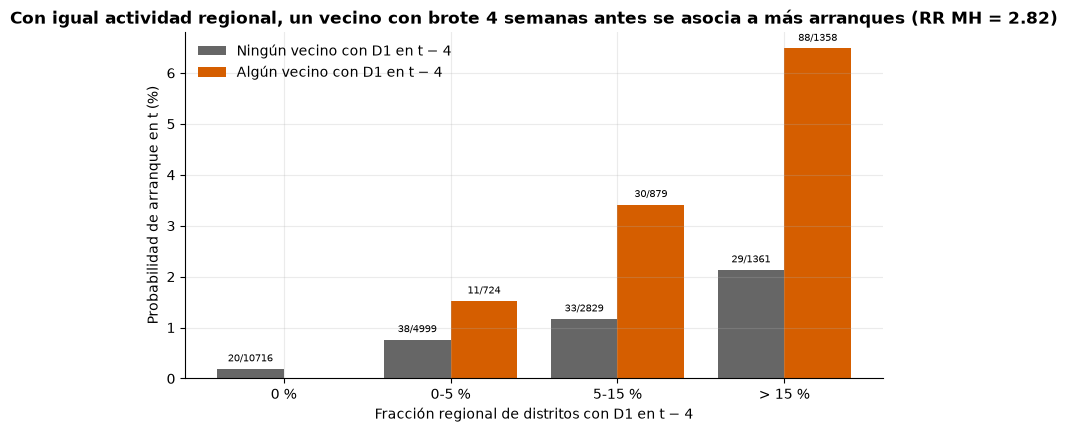

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
estratos = list(tabla5["estrato"].cat.categories) if hasattr(tabla5["estrato"], "cat") else sorted(tabla5["estrato"].unique())
x = np.arange(len(estratos))
for desp, flag, color, lab in [(-0.2, False, COLORES["referencia"], "Ningún vecino con D1 en t − 4"),
                               (0.2, True, COLORES["casos"], "Algún vecino con D1 en t − 4")]:
    s = tabla5[tabla5["vecino"] == flag].set_index("estrato").reindex(estratos)
    ax.bar(x + desp, s["prob"] * 100, width=0.4, color=color, label=lab)
    for i, (p, n, a) in enumerate(zip(s["prob"], s["n"], s["arranques"])):
        if not np.isnan(p):
            ax.text(i + desp, p * 100 + 0.15, f"{int(a)}/{int(n)}", ha="center", fontsize=7)
ax.set_xticks(x, estratos)
ax.set(xlabel=f"Fracción regional de distritos con D1 en t − {H}", ylabel="Probabilidad de arranque en t (%)",
       title=f"Con igual actividad regional, un vecino con brote 4 semanas antes se asocia a más arranques (RR MH = {M['rr_mh_vecino_con_D1_t_menos_4']})")
ax.legend(loc="upper left")
guardar_figura(fig, FASE, "05_vecinos_y_arranques")
plt.show()

**Observación.** Entre las semanas candidatas a arranque, la probabilidad de arranque es mayor cuando algún vecino cercano tenía D1 cuatro semanas antes, **dentro de cada estrato** de actividad regional. La razón de riesgos estratificada se mantiene claramente por encima de 1: su intervalo por bootstrap de temporadas excluye el 1, lo mismo pasa al dejar afuera cada temporada con arranques, y también cuando las candidatas se definen solo con información hasta t − 4 (cifras arriba). En los estratos altos los arranques con vecino son decenas, así que las proporciones de cada estrato tienen incertidumbre.
**Hipótesis.** Es una asociación compatible con propagación entre distritos o con condiciones locales compartidas. No es causal, y el estrato regional controla la confusión solo en parte.
**Implicación.**
- La información rezagada de los vecinos (con rezago ≥ horizonte) es el candidato más directo para mejorar la anticipación de **arranques**, donde la persistencia no ayuda (fase 3).
- La forma de construirla (k vecinos, radio, pesos, qué medida del vecino) se decide en feature engineering, calculándola solo con información pasada.

In [11]:
ruta = guardar_metricas(FASE, M)
print("Métricas guardadas en", ruta.relative_to(ruta.parents[3]))

Métricas guardadas en docs\eda\metricas\fase4_espacial.json
